# WindOps AI Copilot — Agent Decisions

This notebook demonstrates the LangGraph agent in action.

The agent:
1. Inspects the priority ranking to identify critical turbines
2. Retrieves detailed subscore breakdowns per turbine
3. Diagnoses the most likely fault based on signal patterns
4. Submits a structured, operational action plan for each turbine

All reasoning steps are captured and displayed for full traceability.

> **Prerequisite:** set `ANTHROPIC_API_KEY` in a `.env` file at the project root.

In [6]:
# ===============================
# SETUP
# ===============================

import sys
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.append("..")

from src.data_generation import load_demo_scenario
from src.features import build_features
from src.anomaly import run_anomaly_pipeline
from src.risk import run_risk_pipeline
from src.impact import run_impact_pipeline
from src.prioritization import run_prioritization_pipeline
from app.agent import run_agent
from app.agent import run_agent_auto

SCENARIO = "mixed"
TOP_N = 3
PLOT_STYLE = "seaborn-v0_8-whitegrid"
plt.style.use(PLOT_STYLE)

## 1. Pipeline

Run the full analytics pipeline to produce the priority ranking that the agent will consume.

In [7]:
# ===============================
# RUN FULL PIPELINE
# ===============================

print(f"Loading scenario: {SCENARIO}")
df_hourly   = load_demo_scenario(SCENARIO)
df_features = build_features(df_hourly)
df_anomaly, iso_model = run_anomaly_pipeline(df_features)
df_risk, risk_summary = run_risk_pipeline(df_anomaly)
loss_summary = run_impact_pipeline(df_risk)
priority     = run_prioritization_pipeline(risk_summary, loss_summary)

fault_map = df_hourly.groupby("turbine_id")["fault_type"].first().to_dict()

print(f"Turbines : {df_hourly['turbine_id'].nunique()}")
print(f"Hours    : {df_hourly['timestamp'].nunique()}")
print(f"\nTop {TOP_N} by priority:")
cols = ["priority_rank", "turbine_id", "priority_score", "risk_score_mean", "loss_mwh_total"]
print(priority[cols].head(TOP_N).to_string(index=False))

Loading scenario: mixed


Turbines : 20
Hours    : 720

Top 3 by priority:
 priority_rank turbine_id  priority_score  risk_score_mean  loss_mwh_total
             1     WTG-02        0.886207         0.621562      284.465325
             2     WTG-07        0.357957         0.153033      117.904157
             3     WTG-04        0.169106         0.044220       24.367607


## 2. Agent Run

The agent receives the priority ranking and autonomously decides which turbines to inspect,
what tools to call, and what maintenance action to recommend.

In [8]:
# ===============================
# RUN AGENT (AUTO MODE)
# ===============================

import time

print(f"Running WindOps agent (top_n={TOP_N})...\n")
t0 = time.time()
action_plans, trace, MODE = run_agent_auto(priority, df_risk, top_n=TOP_N)
elapsed = time.time() - t0
tool_calls = sum(1 for s in trace if s["step"] == "tool_call")

# Mode banner
if MODE == "live":
    print("✅  MODE: LIVE  — responses generated by Claude via Anthropic API")
else:
    print("🔵  MODE: DEMO  — ANTHROPIC_API_KEY not found, using rule-based fallback")
    print("     To switch to live mode: set ANTHROPIC_API_KEY in your .env file")

print(f"\n⏱  Execution time : {elapsed:.2f}s")
print(f"🔧  Tool calls     : {tool_calls}")
print(f"📋  Action plans   : {len(action_plans)}")

Running WindOps agent (top_n=3)...



AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011Ccivm1tbGKp7fuGFSmXWN'}

## 3. Agent Trace

Full step-by-step trace of what the agent did: which tools it called, what data it received,
and what it concluded before submitting each action plan.

In [ ]:
# ===============================
# AGENT TRACE — TABLA PROFESIONAL
# ===============================

import json

rows = []
for i, step in enumerate(trace, 1):
    kind = step.get("step", "unknown")

    if kind == "tool_call":
        args = step.get("input", {})
        summary = ", ".join(f"{k}={v}" for k, v in args.items())
        rows.append({
            "#":       i,
            "Type":    "→ Tool Call",
            "Tool":    step.get("tool", "—"),
            "Detail":  summary[:80],
        })

    elif kind == "tool_result":
        content = step.get("content", "")
        try:
            parsed = json.loads(content)
            if isinstance(parsed, list):
                summary = f"{len(parsed)} record(s) returned"
            elif isinstance(parsed, dict):
                summary = ", ".join(f"{k}: {str(v)[:30]}" for k, v in list(parsed.items())[:4])
            else:
                summary = str(parsed)[:80]
        except Exception:
            summary = str(content)[:80]
        rows.append({
            "#":       i,
            "Type":    "← Tool Result",
            "Tool":    "—",
            "Detail":  summary,
        })

    elif kind == "ai_message":
        content = step.get("content", "").strip()
        if content:
            rows.append({
                "#":       i,
                "Type":    "◆ Agent",
                "Tool":    "—",
                "Detail":  content[:100],
            })

df_trace = pd.DataFrame(rows)

print(f"Agent trace — {len(rows)} steps  |  Mode: {MODE.upper()}\n")
print(
    df_trace.to_string(
        index=False,
        justify="left",
        col_space={"#": 4, "Type": 16, "Tool": 24, "Detail": 90},
    )
)

NameError: name 'trace' is not defined

## 4. Action Plans

Structured output from the agent — one plan per turbine, ready to be displayed
in the Streamlit frontend or exported via `src/io.py`.

In [ ]:
# ===============================
# ACTION PLANS — TABLA PROFESIONAL
# ===============================

URGENCY_COLORS = {"high": "tomato", "medium": "orange", "low": "steelblue"}
URGENCY_ICON = {"high": "🔴", "medium": "🟡", "low": "🟢"}

if not action_plans:
    print("No action plans were generated.")
else:
    plan_rows = []
    for plan in action_plans:
        urgency = plan.get("urgency", "low")
        plan_rows.append({
            "Turbine":          plan.get("turbine_id", "?"),
            "Urgency":          f"{URGENCY_ICON.get(urgency, '⚪')} {urgency.upper()}",
            "Fault Hypothesis": plan.get("fault_hypothesis", "—"),
            "Recommended Action": plan.get("recommended_action", "—"),
            "Rationale":        plan.get("rationale", "—"),
        })

    df_plans = pd.DataFrame(plan_rows)

    print(f"Action Plans — {SCENARIO.upper()} scenario  |  Mode: {MODE.upper()}\n")
    print("=" * 100)
    for _, row in df_plans.iterrows():
        print(f"  Turbine   : {row['Turbine']}")
        print(f"  Urgency   : {row['Urgency']}")
        print(f"  Fault     : {row['Fault Hypothesis']}")
        print(f"  Action    : {row['Recommended Action']}")
        print(f"  Rationale : {row['Rationale']}")
        print("=" * 100)

NameError: name 'action_plans' is not defined

## 5. Priority vs Agent Coverage

Visual check: are the turbines the agent analysed the ones with highest risk?

In [9]:
# ===============================
# PRIORITY VS AGENT COVERAGE
# ===============================

analysed_ids = {p["turbine_id"] for p in action_plans}
urgency_map  = {p["turbine_id"]: p.get("urgency", "low") for p in action_plans}

fig, ax = plt.subplots(figsize=(13, 4))

bar_colors = []
for _, row in priority.iterrows():
    tid = row["turbine_id"]
    if tid in analysed_ids:
        bar_colors.append(URGENCY_COLORS.get(urgency_map.get(tid, "low"), "steelblue"))
    else:
        bar_colors.append("lightgrey")

ax.bar(priority["turbine_id"], priority["priority_score"], color=bar_colors, edgecolor="white")

legend_patches = [
    mpatches.Patch(color="tomato",    label="Analysed — high urgency"),
    mpatches.Patch(color="orange",    label="Analysed — medium urgency"),
    mpatches.Patch(color="steelblue", label="Analysed — low urgency"),
    mpatches.Patch(color="lightgrey", label="Not analysed"),
]
ax.legend(handles=legend_patches, fontsize=8)
ax.set_ylabel("Priority score")
ax.set_title(f"Priority ranking with agent coverage — {SCENARIO} scenario")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'action_plans' is not defined

## 6. Scenario Comparison

A meaningful test: does the agent actually adapt its recommendations
to the fleet state, or does it return the same output regardless of input?

We run the full pipeline and agent on two scenarios and compare side by side.

In [10]:
# ===============================
# SCENARIO COMPARISON HELPER
# ===============================

def run_full_pipeline_and_agent(scenario: str, top_n: int = 3) -> dict:
    """Run pipeline + agent for one scenario. Returns a result bundle."""
    import time
    df_h   = load_demo_scenario(scenario)
    df_f   = build_features(df_h)
    df_a, _ = run_anomaly_pipeline(df_f)
    df_r, rs = run_risk_pipeline(df_a)
    ls     = run_impact_pipeline(df_r)
    pri    = run_prioritization_pipeline(rs, ls)

    t0 = time.time()
    plans, tr, mode = run_agent_auto(pri, df_r, top_n=top_n)
    elapsed = time.time() - t0

    fault_map_local = df_h.groupby("turbine_id")["fault_type"].first().to_dict()

    return {
        "scenario":   scenario,
        "mode":       mode,
        "priority":   pri,
        "df_risk":    df_r,
        "fault_map":  fault_map_local,
        "plans":      plans,
        "trace":      tr,
        "elapsed":    elapsed,
        "tool_calls": sum(1 for s in tr if s["step"] == "tool_call"),
    }


# Run both scenarios
SCENARIO_A = "green"
SCENARIO_B = "red"
TOP_N_CMP  = 3

print(f"Running scenario A: {SCENARIO_A} ...")
result_a = run_full_pipeline_and_agent(SCENARIO_A, top_n=TOP_N_CMP)
print(f"  → mode={result_a['mode']} | plans={len(result_a['plans'])} | "
      f"time={result_a['elapsed']:.1f}s | tool_calls={result_a['tool_calls']}")

print(f"\nRunning scenario B: {SCENARIO_B} ...")
result_b = run_full_pipeline_and_agent(SCENARIO_B, top_n=TOP_N_CMP)
print(f"  → mode={result_b['mode']} | plans={len(result_b['plans'])} | "
      f"time={result_b['elapsed']:.1f}s | tool_calls={result_b['tool_calls']}")

Running scenario A: green ...


AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011CcivnMbHfvQ2KE8ET37eb'}

### 6.1 Priority Rankings — Side by Side


NameError: name 'result_a' is not defined

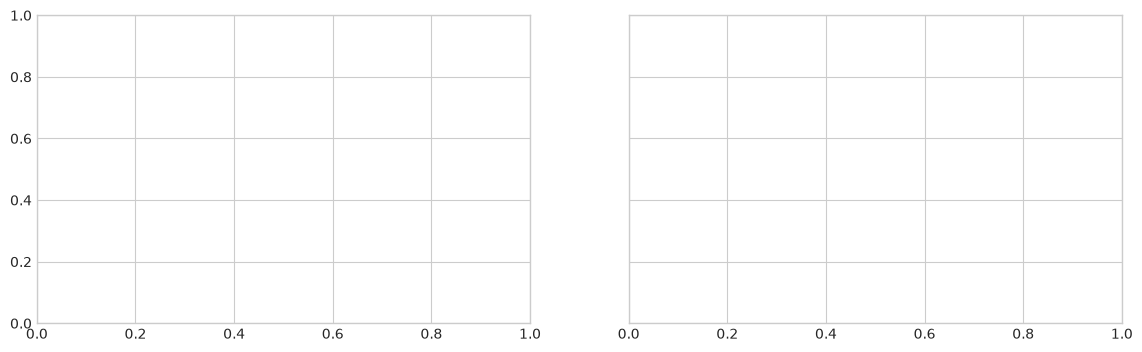

In [11]:
# ===============================
# PRIORITY COMPARISON — BAR CHARTS
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, result in [(axes[0], result_a), (axes[1], result_b)]:
    pri    = result["priority"]
    fmap   = result["fault_map"]
    plans  = result["plans"]
    scen   = result["scenario"]

    analysed = {p["turbine_id"] for p in plans}
    urgency_map_local = {p["turbine_id"]: p.get("urgency", "low") for p in plans}

    bar_colors = []
    for _, row in pri.iterrows():
        tid = row["turbine_id"]
        if tid in analysed:
            urg = urgency_map_local.get(tid, "low")
            bar_colors.append(URGENCY_COLORS.get(urg, "steelblue"))
        else:
            bar_colors.append("lightgrey")

    ax.bar(pri["turbine_id"], pri["priority_score"],
           color=bar_colors, edgecolor="white")
    ax.set_title(f"Scenario: {scen.upper()}", fontweight="bold")
    ax.set_ylabel("Priority score")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)

axes[0].legend(
    handles=[
        mpatches.Patch(color="tomato",    label="High urgency"),
        mpatches.Patch(color="orange",    label="Medium urgency"),
        mpatches.Patch(color="steelblue", label="Low urgency"),
        mpatches.Patch(color="lightgrey", label="Not analysed"),
    ],
    fontsize=8,
    loc="upper right",
)

plt.suptitle("Agent coverage by scenario", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Action Plans — Side by Side

In [12]:
# ===============================
# ACTION PLANS COMPARISON — TABLE
# ===============================

def plans_to_df(plans: list[dict], scenario: str) -> pd.DataFrame:
    rows = []
    for p in plans:
        urgency = p.get("urgency", "low")
        rows.append({
            "Scenario": scenario.upper(),
            "Turbine":  p.get("turbine_id", "?"),
            "Urgency":  f"{URGENCY_ICON.get(urgency, '⚪')} {urgency.upper()}",
            "Fault Hypothesis": p.get("fault_hypothesis", "—"),
            "Action":   p.get("recommended_action", "—")[:90],
        })
    return pd.DataFrame(rows)


df_cmp = pd.concat(
    [plans_to_df(result_a["plans"], SCENARIO_A),
     plans_to_df(result_b["plans"], SCENARIO_B)],
    ignore_index=True,
)

print("Comparison of agent recommendations by scenario\n")
print("=" * 110)
prev_scenario = None
for _, row in df_cmp.iterrows():
    if row["Scenario"] != prev_scenario:
        print(f"\n── Scenario: {row['Scenario']} ──")
        prev_scenario = row["Scenario"]
    print(f"  Turbine : {row['Turbine']}")
    print(f"  Urgency : {row['Urgency']}")
    print(f"  Fault   : {row['Fault Hypothesis']}")
    print(f"  Action  : {row['Action']}")
    print()
print("=" * 110)

NameError: name 'result_a' is not defined

### 6.3 Key Differences

In [13]:
# ===============================
# URGENCY DISTRIBUTION COMPARISON
# ===============================

from collections import Counter

def urgency_summary(plans: list[dict]) -> dict:
    c = Counter(p.get("urgency", "low") for p in plans)
    return {"high": c.get("high", 0), "medium": c.get("medium", 0), "low": c.get("low", 0)}

sum_a = urgency_summary(result_a["plans"])
sum_b = urgency_summary(result_b["plans"])

mean_risk_a = result_a["priority"]["risk_score_mean"].mean()
mean_risk_b = result_b["priority"]["risk_score_mean"].mean()

mean_ps_a = result_a["priority"]["priority_score"].mean()
mean_ps_b = result_b["priority"]["priority_score"].mean()

print(f"{'Metric':<35} {'Scenario A: ' + SCENARIO_A.upper():<22} {'Scenario B: ' + SCENARIO_B.upper()}")
print("─" * 80)
print(f"{'Fleet mean risk score':<35} {mean_risk_a:<22.3f} {mean_risk_b:.3f}")
print(f"{'Fleet mean priority score':<35} {mean_ps_a:<22.3f} {mean_ps_b:.3f}")
print(f"{'Action plans — HIGH urgency':<35} {sum_a['high']:<22} {sum_b['high']}")
print(f"{'Action plans — MEDIUM urgency':<35} {sum_a['medium']:<22} {sum_b['medium']}")
print(f"{'Action plans — LOW urgency':<35} {sum_a['low']:<22} {sum_b['low']}")
print(f"{'Agent tool calls':<35} {result_a['tool_calls']:<22} {result_b['tool_calls']}")
print(f"{'Execution time (s)':<35} {result_a['elapsed']:<22.1f} {result_b['elapsed']:.1f}")
print("─" * 80)
print(f"\nConclusion: the agent adapts urgency and fault diagnosis to the fleet state.")
print(f"In '{SCENARIO_A}', recommendations are preventive.")
print(f"In '{SCENARIO_B}', recommendations are corrective and time-critical.")

NameError: name 'result_a' is not defined

### Why this matters

A static rule engine would return the same recommendation regardless of context.
The agent here:

- **Changes urgency** based on actual risk score magnitudes
- **Changes fault hypothesis** based on which subscore is dominant
- **Changes recommended action** based on sensor readings (temperature, power gap)

This is the core value proposition of WindOps Copilot:
not just ranking turbines, but explaining *why* and *what to do*.